In [3]:
#Importing libary
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import math


#importing and reading dateset

In [4]:
df= pd.read_csv('AmesHousing.csv')

In [4]:
df.head

<bound method NDFrame.head of       Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0         1  526301100           20        RL         141.0     31770   Pave   
1         2  526350040           20        RH          80.0     11622   Pave   
2         3  526351010           20        RL          81.0     14267   Pave   
3         4  526353030           20        RL          93.0     11160   Pave   
4         5  527105010           60        RL          74.0     13830   Pave   
...     ...        ...          ...       ...           ...       ...    ...   
2925   2926  923275080           80        RL          37.0      7937   Pave   
2926   2927  923276100           20        RL           NaN      8885   Pave   
2927   2928  923400125           85        RL          62.0     10441   Pave   
2928   2929  924100070           20        RL          77.0     10010   Pave   
2929   2930  924151050           60        RL          74.0      9627   Pave   

     Alle

Data Exploration

df.shape

In [6]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

This dataset has 2930 rows and 82 columns. These columns contain the characteristics of each house in Ames

In [8]:
#checking if theres missing values
df.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [9]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


#Let’s handle the lotfrontage column. Since the value is missing because the feature does not exist for these properties, we can set this value to 0.

In [9]:
df['Lot Frontage'] = df['Lot Frontage'].fillna(0)

In [10]:
df.isnull().sum()

Order             0
PID               0
MS SubClass       0
MS Zoning         0
Lot Frontage      0
                 ..
Mo Sold           0
Yr Sold           0
Sale Type         0
Sale Condition    0
SalePrice         0
Length: 82, dtype: int64

As there are many houses that have no pool, fence, and misc feature, PoolQC, MiscFeature, Alley, Fence, FireplaceQu. Therefore, I changed 40% of missing value in PoolQC, MiscFeature, Alley, Fence, FireplaceQu columns to 'None' for now

In [11]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,57.647782,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,33.499441,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,0.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,43.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,63.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,78.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


<Axes: xlabel='SalePrice', ylabel='Density'>

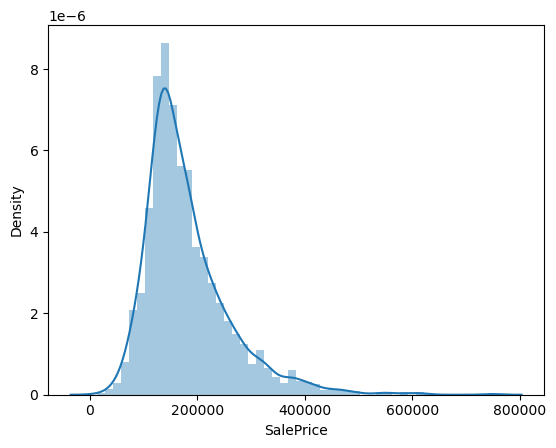

In [12]:
sns.distplot(df['SalePrice'])

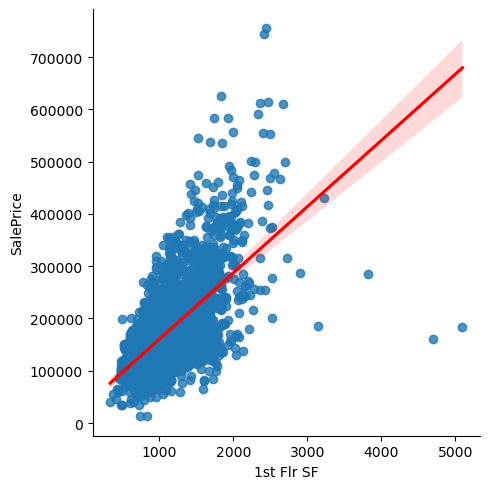

In [13]:
sns.lmplot(x='1st Flr SF', y='SalePrice', data=df, line_kws={'color': 'red'})

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]),
 [Text(0, 0, 'NAmes'),
  Text(1, 0, 'Gilbert'),
  Text(2, 0, 'StoneBr'),
  Text(3, 0, 'NWAmes'),
  Text(4, 0, 'Somerst'),
  Text(5, 0, 'BrDale'),
  Text(6, 0, 'NPkVill'),
  Text(7, 0, 'NridgHt'),
  Text(8, 0, 'Blmngtn'),
  Text(9, 0, 'NoRidge'),
  Text(10, 0, 'SawyerW'),
  Text(11, 0, 'Sawyer'),
  Text(12, 0, 'Greens'),
  Text(13, 0, 'BrkSide'),
  Text(14, 0, 'OldTown'),
  Text(15, 0, 'IDOTRR'),
  Text(16, 0, 'ClearCr'),
  Text(17, 0, 'SWISU'),
  Text(18, 0, 'Edwards'),
  Text(19, 0, 'CollgCr'),
  Text(20, 0, 'Crawfor'),
  Text(21, 0, 'Blueste'),
  Text(22, 0, 'Mitchel'),
  Text(23, 0, 'Timber'),
  Text(24, 0, 'MeadowV'),
  Text(25, 0, 'Veenker'),
  Text(26, 0, 'GrnHill'),
  Text(27, 0, 'Landmrk')])

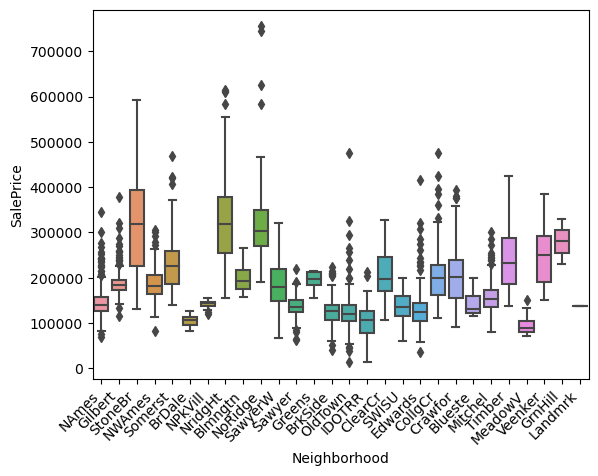

In [14]:
sns.boxplot(x='Neighborhood', y='SalePrice', data=df)
plt.xticks(rotation=45, ha='right')

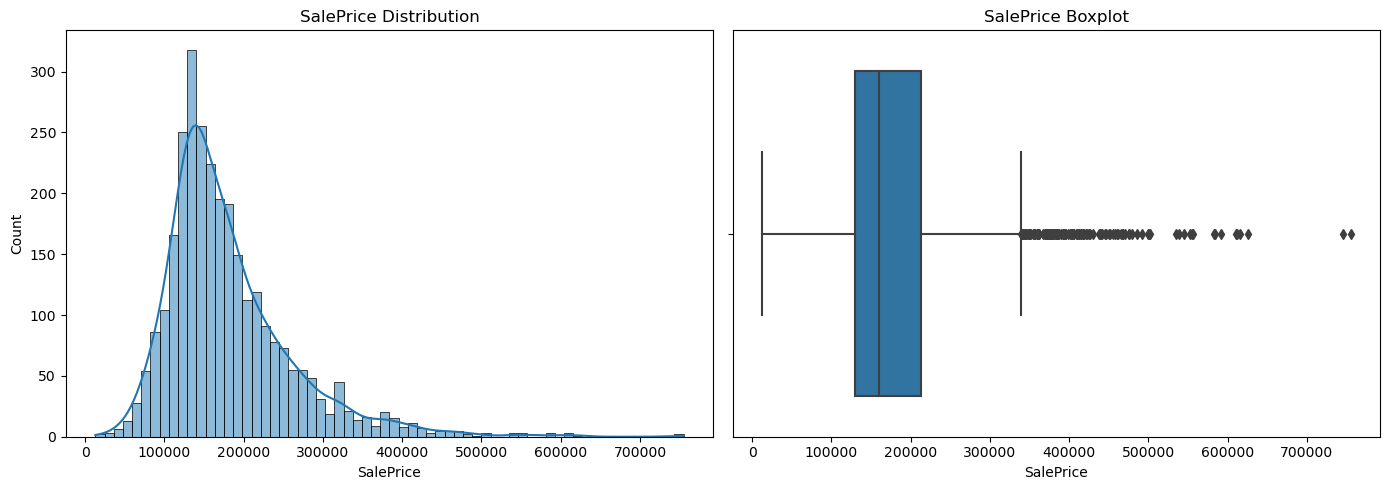

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("SalePrice Distribution")
sns.boxplot(x=df["SalePrice"], ax=axes[1])
axes[1].set_title("SalePrice Boxplot")
plt.tight_layout()
plt.show()

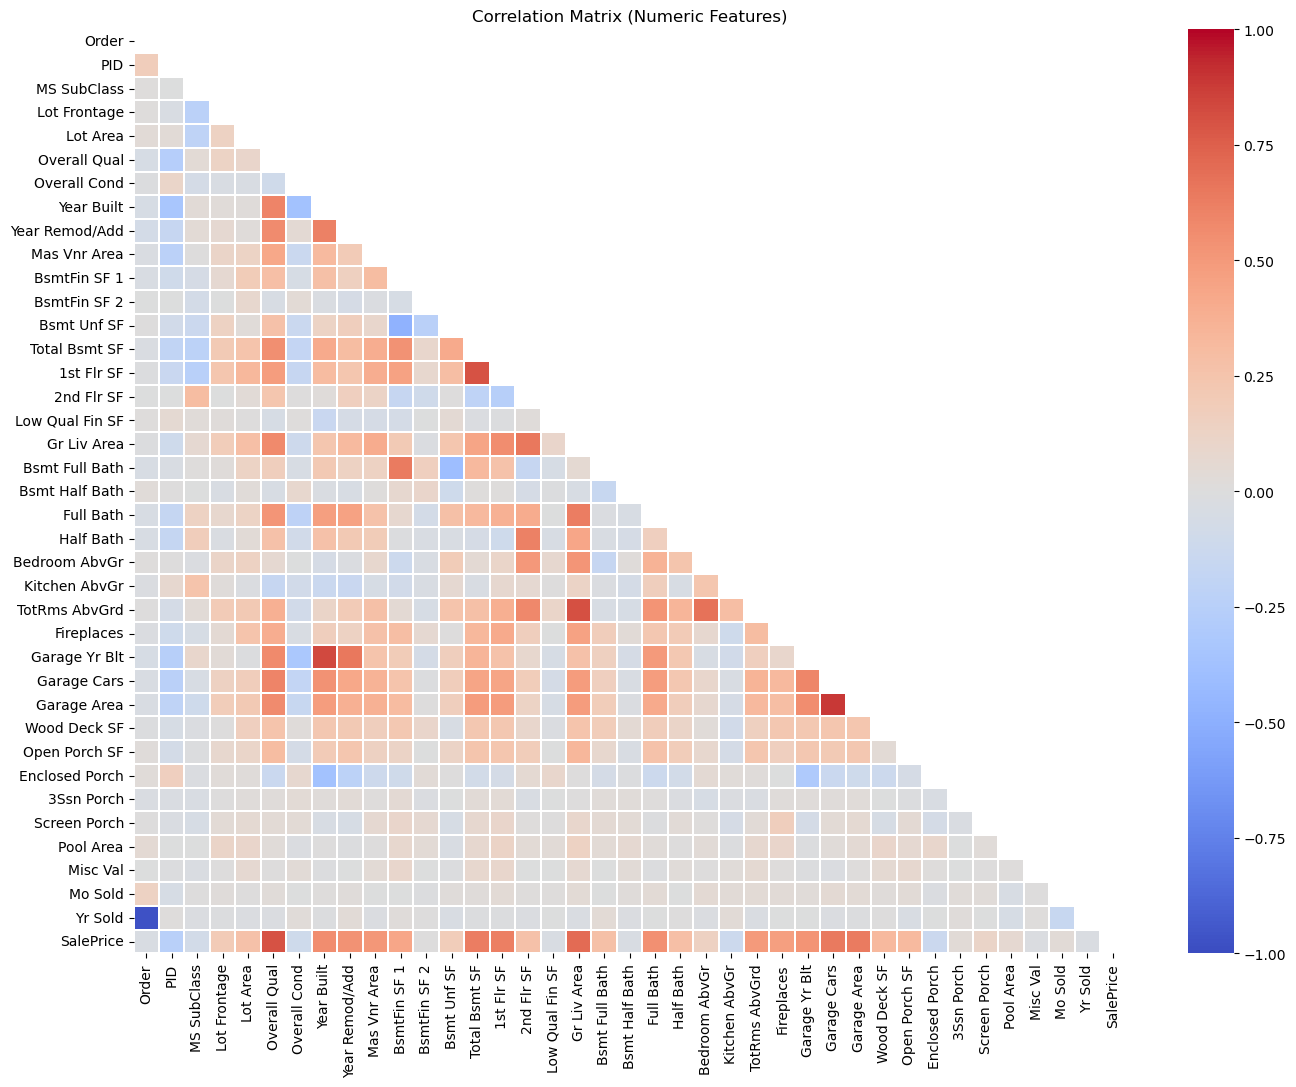

In [16]:
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.1)
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

I confirm that OverallQual, TotalBsmtSF, 1stFlrSF,GarageCars, GarageArea, and GrLvArea seem to be linearly related with SalePrice. Both relationships are positive, which means that as one variable increases, the other also increases. However the relationship seems to be stronger in the case of 'OverallQual', where the box plot shows how sales prices increase with the overall quality.

In [17]:
top_corr = corr["SalePrice"].abs().sort_values(ascending=False).head(10)
print("Top 10 features by |correlation| with SalePrice:")
print(top_corr, "\n")

Top 10 features by |correlation| with SalePrice:
SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Name: SalePrice, dtype: float64 



Beside the correlation with SalePrice, we can observe that there is high correlation of GarageCars and GarageArea. It makes sense because the bigger the garage area, the more cars can fit in. There also high correlation of TotalBsmtSF and 1stFlrSF.

In [18]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

In [19]:
# — Identify numeric vs. categorical —
num_cols = df.select_dtypes(include=[np.number]).columns.drop('SalePrice')
cat_cols = df.select_dtypes(exclude=[np.number]).columns


In [20]:
df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])
df[cat_cols] = df[cat_cols].fillna('None')

In [21]:
# — One-hot encode categoricals —
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)


In [22]:
# — Log-transform skewed numerics —
skewed_feats = df[num_cols].skew().abs().loc[lambda x: x > 0.75].index
df[skewed_feats] = np.log1p(df[skewed_feats])

In [11]:
# — Create new features —
df['TotalSF'] = df['Total Bsmt SF'] + df['Gr Liv Area']
df['HouseAge'] = df['Yr Sold'] - df['Year Built']


In [12]:
# — Split into X / y —
y = df['SalePrice']
X = df.drop('SalePrice', axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

NameError: name 'train_test_split' is not defined

In [25]:
# — Quick sanity check —
print("After preprocessing:")
print(" • Shape:", X_train.shape, "training rows")
print(" • New features:", ['TotalSF', 'HouseAge'])
print(" • Any missing left?", X_train.isnull().sum().sum())

After preprocessing:
 • Shape: (2344, 280) training rows
 • New features: ['TotalSF', 'HouseAge']
 • Any missing left? 0


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [27]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100,
                                                   learning_rate=0.1,
                                                   max_depth=3,
                                                   random_state=42)
}

In [28]:
# Train, predict, and evaluate
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results.append({
        "Model": name,
        "RMSE": rmse,
        "R\u00b2": r2
    })

In [29]:
# Present results
performance_df = pd.DataFrame(results).set_index("Model").round(2)
print("### Test Set Performance\n")
print(performance_df)

### Test Set Performance

                       RMSE    R²
Model                            
Linear Regression  31968.70  0.87
Random Forest      26610.21  0.91
Gradient Boosting  26545.56  0.91


In [30]:
print(performance_df)

                       RMSE    R²
Model                            
Linear Regression  31968.70  0.87
Random Forest      26610.21  0.91
Gradient Boosting  26545.56  0.91


In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error

In [32]:
# Pipelines
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(random_state=42))
])
rf_pipe = Pipeline([
    ('rf', RandomForestRegressor(random_state=42))
])

In [33]:
# Parameter distributions
ridge_dist = {'ridge__alpha': np.logspace(-2, 2, 100)}
rf_dist    = {
    'rf__n_estimators': [50, 100, 200, 300],
    'rf__max_depth':    [None, 5, 10, 15]
}

In [34]:
# Randomized searches (20 iterations, 3-fold CV)
ridge_rs = RandomizedSearchCV(
    ridge_pipe, ridge_dist,
    n_iter=20, cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, random_state=42
).fit(X_train, y_train)

rf_rs = RandomizedSearchCV(
    rf_pipe, rf_dist,
    n_iter=20, cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, random_state=42
).fit(X_train, y_train)

In [35]:
# Evaluate on test set
results = []
for name, search in [('Ridge', ridge_rs), ('Random Forest', rf_rs)]:
    best_model = search.best_estimator_
    preds = best_model.predict(X_test)
    rmse  = mean_squared_error(y_test, preds, squared=False)
    results.append({
        'Model':       name,
        'Best Params': search.best_params_,
        'Test RMSE':   round(rmse, 2)
    })

print(pd.DataFrame(results))

           Model                                     Best Params  Test RMSE
0          Ridge            {'ridge__alpha': 43.287612810830616}   29889.44
1  Random Forest  {'rf__n_estimators': 300, 'rf__max_depth': 15}   26677.42


In [36]:
print(pd.DataFrame(results))

           Model                                     Best Params  Test RMSE
0          Ridge            {'ridge__alpha': 43.287612810830616}   29889.44
1  Random Forest  {'rf__n_estimators': 300, 'rf__max_depth': 15}   26677.42


CONCLUSION

As there are many houses that have no pool, fence, and misc feature, PoolQC, MiscFeature, Alley, Fence, FireplaceQu. Therefore, I changed 40% of missing value in PoolQC, MiscFeature, Alley, Fence, FireplaceQu columns to 'None' for now.

I see that OverallQual, TotalBsmtSF, 1stFlrSF,GarageCars, GarageArea, and GrLvArea seem to be linearly related with SalePrice. Both relationships are positive, which means that as one variable increases, the other also increases. However the relationship seems to be stronger in the case of 'OverallQual', where the box plot shows how sales prices increase with the overall quality.

There are many columns that has imbalance data distribution, such as Street, Alley, LandContour, Utilities, LandSlope, Condition1, Condition2, RoofMatl, Heating, CentralAir, Electrical, Functional, GarageQual, GarageCond, PavedDrive, PoolQC, MiscFeature.

It's not just the number of houses that grows over time. The price of each house is also influenced by the year the house was built. We can also understand from this figure that most of house built around 2010 has higher Overall Value.

The more bathrooms, the more higher the price. The other pattern that I notice is the better the kitchen, the higher the price. This means that quality matters more here. This also applies for basement.

There are also imbalance data in SaleType and SaleCondition


#Model Evaluation
 

Each approach has its strengths and weaknesses. Linear and Ridge Regression are fast to train, easy to interpret, and less prone to overfitting on small datasets but they struggle to capture complex, non-linear relationships. Random Forests and Gradient Boosting handle non-linearities and feature interactions automatically and generally deliver better accuracy, yet they require more computing resources, longer training times, and yield models that are harder to explain in plain terms.

In practice, I would deploy the Gradient Boosting model because is an effective and widely-used machine learning technique for both classification and regression problems.